# Taller Práctico: Regresión Logística

**Curso:** Maestría en Machine Learning

## 1. Importación de Librerías

In [1]:
pip install ISLP


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
# Librerías para manipulación de datos
import pandas as pd
import numpy as np

# Librerías para visualización
import plotly.express as px
import plotly.graph_objects as go
from matplotlib import pyplot as plt

# Librerías de Machine Learning (scikit-learn)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Librería para cargar el dataset
from ISLP import load_data

## 2. Carga y Preprocesamiento de Datos

In [4]:
# Carga de datos
default_df = load_data('Default')

# Conversión de categóricas a numéricas
df_processed = pd.get_dummies(default_df, columns=['student'], drop_first=True, dtype=int)
df_processed['default'] = df_processed['default'].apply(lambda x: 1 if x == 'Yes' else 0)

# Definición de features y target
X = df_processed[['balance', 'income', 'student_Yes']]
y = df_processed['default']

print("Primeras filas de los datos preprocesados:")
display(X.head())

Primeras filas de los datos preprocesados:


,balance,income,student_Yes
0,729.526495,44361.625074,0
1,817.180407,12106.134700,1
2,1073.549164,31767.138947,0
3,529.250605,35704.493935,0
4,785.655883,38463.495879,0


### División en Conjuntos de Entrenamiento y Testeo

Dividimos los datos ANTES de cualquier preprocesamiento que "aprenda" de los datos, como la estandarización, para evitar fuga de información (data leak).

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de X_test: {X_test.shape}")

Forma de X_train: (8000, 3)
Forma de X_test: (2000, 3)


### Estandarización de Features Numéricos

**Este es un paso crucial.** Estandarizamos las variables `balance` e `income` para que tengan media 0 y desviación estándar 1. Esto asegura que la regularización del modelo se aplique de manera justa.

**Importante:** Ajustamos el `StandardScaler` **únicamente** con los datos de entrenamiento (`X_train`) y luego lo usamos para transformar tanto el conjunto de entrenamiento como el de prueba.

In [6]:
# Instanciamos el escalador
scaler = StandardScaler()

# Columnas a escalar
cols_to_scale = ['balance', 'income']

# Creamos copias para no modificar los dataframes originales
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

# Ajustamos y transformamos los datos de entrenamiento
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])

# Transformamos los datos de prueba con el escalador ya ajustado
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

print("Primeras filas de los datos de entrenamiento escalados:")
display(X_train_scaled.head())

Primeras filas de los datos de entrenamiento escalados:


,balance,income,student_Yes
2720,-0.018061,-0.331140,1
6168,-1.687480,2.194023,0
7723,-0.123917,-0.288274,0
8128,0.155670,0.992420,0
3565,0.449485,-1.673192,1


## 3. Entrenamiento del Modelo de Regresión Logística

Ahora entrenaremos el modelo usando los datos estandarizados.

In [44]:
# Instanciamos y entrenamos el modelo con los datos escalados
log_reg = LogisticRegression(random_state=42)#, solver='liblinear')
log_reg.fit(X_train_scaled, y_train)

print("¡Modelo entrenado exitosamente con datos escalados!")




¡Modelo entrenado exitosamente con datos escalados!


## 4. Evaluación del Modelo

Procedemos a la evaluación completa del modelo sobre el conjunto de prueba escalado.

### 4.1. Matriz de Confusión y Métricas Clave

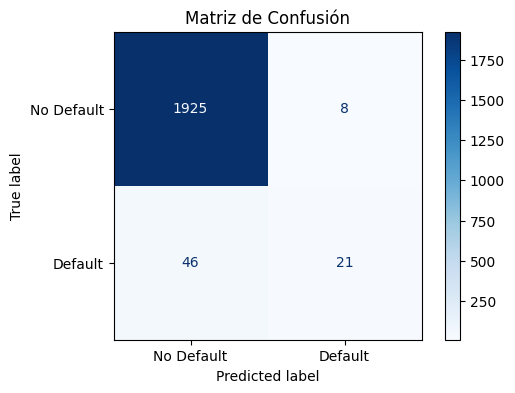


Reporte de Clasificación:
              precision    recall  f1-score   support

  No Default       0.98      1.00      0.99      1933
     Default       0.72      0.31      0.44        67

    accuracy                           0.97      2000
   macro avg       0.85      0.65      0.71      2000
weighted avg       0.97      0.97      0.97      2000



In [8]:
# Realizamos predicciones sobre el conjunto de prueba escalado
y_pred = log_reg.predict(X_test_scaled)

# Calculamos y visualizamos la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Default', 'Default'])
fig, ax = plt.subplots(figsize=(6, 4))
disp.plot(cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusión')
plt.show()

# Imprimimos el reporte de clasificación completo
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

### 4.2. El Impacto del Umbral de Decisión

Reporte de Clasificación con Umbral = 0.2:
              precision    recall  f1-score   support

  No Default       0.99      0.97      0.98      1933
     Default       0.39      0.63      0.48        67

    accuracy                           0.95      2000
   macro avg       0.69      0.80      0.73      2000
weighted avg       0.97      0.95      0.96      2000



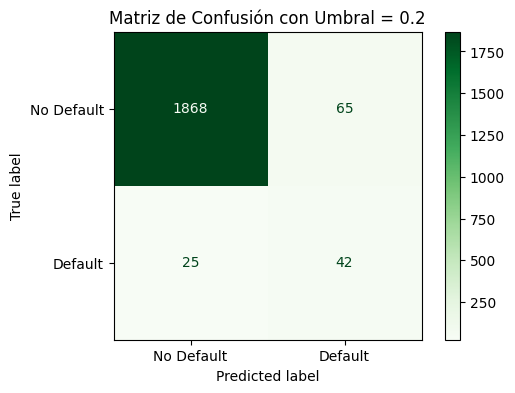

In [9]:
# Obtenemos las probabilidades de predicción para la clase positiva (Default)
y_pred_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

# Aplicamos un nuevo umbral de 0.2 para aumentar el Recall
umbral = 0.2
y_pred_nuevo_umbral = (y_pred_proba >= umbral).astype(int)

print(f"Reporte de Clasificación con Umbral = {umbral}:")
print(classification_report(y_test, y_pred_nuevo_umbral, target_names=['No Default', 'Default']))

# Visualizamos la nueva matriz de confusión
cm_nuevo = confusion_matrix(y_test, y_pred_nuevo_umbral)
disp_nuevo = ConfusionMatrixDisplay(confusion_matrix=cm_nuevo, display_labels=['No Default', 'Default'])
fig, ax = plt.subplots(figsize=(6, 4))
disp_nuevo.plot(cmap='Greens', ax=ax)
ax.set_title(f'Matriz de Confusión con Umbral = {umbral}')
plt.show()

### 4.3. Curva ROC y AUC

In [10]:
# Calculamos la tasa de verdaderos positivos (tpr) y la tasa de falsos positivos (fpr)
fpr, tpr, umbrales = roc_curve(y_test, y_pred_proba)
auc = roc_auc_score(y_test, y_pred_proba)

# Creamos el gráfico con Plotly
fig = go.Figure()
fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'Curva ROC (AUC = {auc:.4f})'))
fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Clasificador Aleatorio', line=dict(dash='dash')))
fig.update_layout(
    title='Curva ROC para el Modelo de Regresión Logística',
    xaxis_title='Tasa de Falsos Positivos (FPR)',
    yaxis_title='Tasa de Verdaderos Positivos (TPR)',
    template='plotly_white'
)
fig.show()

In [11]:
pd.DataFrame({
    'Umbral': umbrales,
    'FPR': fpr,
    'TPR': tpr
})  # Mostramos las primeras filas de los umbrales y sus correspondientes FPR y TPR

,Umbral,FPR,TPR
0,inf,0.000000,0.000000
1,0.904982,0.000000,0.014925
2,0.876104,0.000000,0.029851
3,0.861995,0.000517,0.029851
4,0.723316,0.000517,0.179104
...,...,...,...
87,0.007660,0.320228,0.970149
88,0.007620,0.320228,0.985075
89,0.007012,0.332644,0.985075
90,0.007008,0.332644,1.000000


## 5. Regularización

El hiperparámetro `C` en `scikit-learn` es el inverso de la fuerza de regularización $\lambda$. Un valor de `C` pequeño implica una regularización más fuerte. Ahora que los datos están escalados, la comparación de coeficientes es mucho más justa.

In [12]:
# Modelo con regularización L2 (Ridge) - C=1.0 (default)
log_reg_l2 = LogisticRegression(penalty='l2', C=1.0, solver='liblinear', random_state=42).fit(X_train_scaled, y_train)

# Modelo con regularización L1 (Lasso) - C=1.0 (default)
log_reg_l1 = LogisticRegression(penalty='l1', C=1.0, solver='liblinear', random_state=42).fit(X_train_scaled, y_train)

# Ahora con regularización más fuerte (C=0.1)
log_reg_l2_strong = LogisticRegression(penalty='l2', C=0.1, solver='liblinear', random_state=42).fit(X_train_scaled, y_train)
log_reg_l1_strong = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', random_state=42).fit(X_train_scaled, y_train)

# Creamos un DataFrame para comparar los coeficientes
coef_df = pd.DataFrame({
    'Predictor': X.columns,
    'Coef_L2 (C=1.0)': log_reg_l2.coef_[0],
    'Coef_L1 (C=1.0)': log_reg_l1.coef_[0],
    'Coef_L2_fuerte (C=0.1)': log_reg_l2_strong.coef_[0],
    'Coef_L1_fuerte (C=0.1)': log_reg_l1_strong.coef_[0]
})

print("Comparación de Coeficientes con Regularización (Datos Escalados):")
display(coef_df)

Comparación de Coeficientes con Regularización (Datos Escalados):


,Predictor,Coef_L2 (C=1.0),Coef_L1 (C=1.0),Coef_L2_fuerte (C=0.1),Coef_L1_fuerte (C=0.1)
0,balance,2.594626,2.709366,1.921343,2.389894
1,income,-0.054058,-0.004069,-0.106268,0.002709
2,student_Yes,-0.658059,-0.561404,-0.670900,-0.323989


**Análisis:**
- Ahora los coeficientes son directamente comparables en magnitud.
- Se puede observar claramente cómo al aumentar la fuerza de la regularización (disminuir `C`), los coeficientes se "encogen" hacia cero.
- La regularización L1 es más agresiva y puede llevar coeficientes a cero, realizando una selección de variables.

## 6. Preguntas y Desafíos para Experimentar

Ahora te toca a vos. Intentá responder a las siguientes preguntas modificando el código anterior para fijar lo que vimos:

1.  **Fuerza de Regularización vs. Rendimiento:** Creá un gráfico que muestre cómo cambia el AUC del modelo a medida que varías el hiperparámetro `C` (p. ej. `[0.001, 0.01, 0.1, 1, 10, 100]`). ¿Encontrás un valor óptimo para `C`?
2.  **Otros Escaladores:** En lugar de `StandardScaler`, prueba con `MinMaxScaler` de `sklearn.preprocessing`. ¿Cambian los resultados de rendimiento? ¿Y los coeficientes del modelo?
3.  **Selección de Predictores:** Entrená el modelo usando solo `balance` y `student_Yes` (ambos escalados). ¿Cuánto cae el rendimiento (AUC) al quitar la variable `income`? ¿Confirma esto que `income` es el predictor menos importante?

## 7. Ejercicios Propuestos

1.  Explicá con tus propias palabras por qué el accuracy no es una buena métrica para evaluar un modelo en un dataset desbalanceado como `Default`.
2.  Si un banco te pide un modelo que minimice la cantidad de clientes en default que no son detectados, ¿en qué métrica te enfocarías (Precisión o Recall)? ¿Y cómo ajustarías el umbral de decisión?
3.  Cargá un nuevo dataset de clasificación de `scikit-learn` (por ejemplo, `load_breast_cancer`) y realizá un análisis completo: estandarización, entrenamiento, evaluación con matriz de confusión y reporte de clasificación.
4.  ¿Qué representa un punto en la esquina superior izquierda de la curva ROC? ¿Y un punto en la línea diagonal?
5.  ¿Por qué es fundamental ajustar (`fit`) el `StandardScaler` únicamente con los datos de entrenamiento y no con todo el dataset?
6.  Creá un bucle `for` que itere sobre una lista de umbrales (ej. `[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]`). Para cada umbral, calculá y guardá la Precisión y el Recall para la clase 'Default'. Luego, graficá cómo cambian estas dos métricas a medida que varía el umbral (Precision-Recall Curve).
7.  Usando los coeficientes del modelo `log_reg` (entrenado con datos escalados), interpretá el coeficiente de la variable `balance`. ¿Qué significa un aumento de una desviación estándar en el `balance` en términos del odds ratio de default?
8.  Explicá la diferencia fundamental entre la regularización L1 y L2 en términos de su efecto sobre los coeficientes del modelo.
9.  Si tuvieras dos modelos, uno con AUC de 0.85 y otro con AUC de 0.75, ¿cuál elegirías y por qué? ¿Bajo qué circunstancias podrías preferir el de 0.75?

## Respuestas punto 6

In [ ]:

# Punto 1 - AUC vs C

cs = [0.001, 0.01, 0.1, 1, 10, 100]
aucs = []

for c in cs:
    modelo = LogisticRegression(C=c, random_state=42)
    modelo.fit(X_train_scaled, y_train)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    aucs.append(auc)
    print(f"C={c} -> AUC={auc:.4f}")






#El AUC se mantiene estable para C entre 0.1 y 100. Con C muy pequeño (0.001), la regularización es tan fuerte que el modelo pierde capacidad predictiva.

C=0.001 -> AUC=0.9438
C=0.01 -> AUC=0.9477
C=0.1 -> AUC=0.9487
C=1 -> AUC=0.9485
C=10 -> AUC=0.9485
C=100 -> AUC=0.9485


# Armo el gráfico

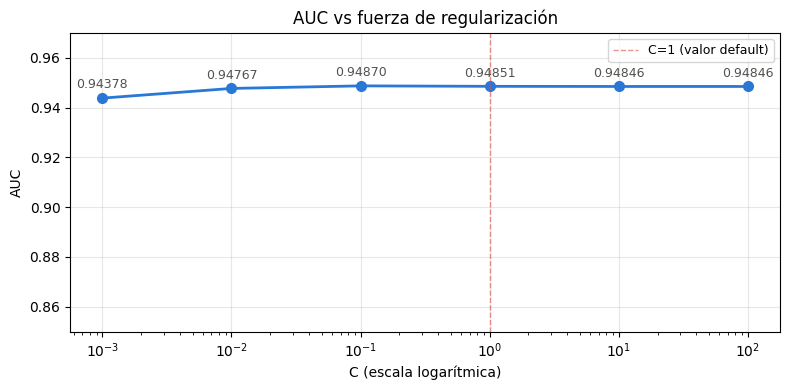

In [36]:
import matplotlib.pyplot as plt

cs = [0.001, 0.01, 0.1, 1, 10, 100]
aucs = []

for c in cs:
    modelo = LogisticRegression(C=c, random_state=42)
    modelo.fit(X_train_scaled, y_train)
    y_proba = modelo.predict_proba(X_test_scaled)[:, 1]
    auc = roc_auc_score(y_test, y_proba)
    aucs.append(auc)

fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(cs, aucs, marker='o', linewidth=2, markersize=7, color='#2a78d6')

for c, auc in zip(cs, aucs):
    ax.annotate(f'{auc:.5f}', xy=(c, auc), xytext=(0, 7),
                textcoords='offset points', ha='center', fontsize=9, color='#52514e')

ax.set_xscale('log')
ax.set_xlabel('C (escala logarítmica)')
ax.set_ylabel('AUC')
ax.set_title('AUC vs fuerza de regularización')
ax.set_ylim(0.85, 0.97)
ax.grid(True, alpha=0.3)
ax.axvline(x=1, color='#e34948', linestyle='--', linewidth=1, alpha=0.6, label='C=1 (valor default)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

In [48]:
# Punto 2 - MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

scaler_mm = MinMaxScaler()

X_train_mm = X_train.copy()
X_test_mm = X_test.copy()

X_train_mm[cols_to_scale] = scaler_mm.fit_transform(X_train[cols_to_scale])
X_test_mm[cols_to_scale] = scaler_mm.transform(X_test[cols_to_scale])

modelo_mm = LogisticRegression(random_state=42)
modelo_mm.fit(X_train_mm, y_train)
y_proba_mm = modelo_mm.predict_proba(X_test_mm)[:, 1]

print(f"AUC con StandardScaler: {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"AUC con MinMaxScaler:   {roc_auc_score(y_test, y_proba_mm):.4f}")


coef_comparacion = pd.DataFrame({
    'Predictor': X.columns,
    'Coef_StandardScaler': log_reg.coef_[0],
    'Coef_MinMaxScaler': modelo_mm.coef_[0]
})

print("\nComparación de coeficientes:")
display(coef_comparacion)

print("El AUC es prácticamente idéntico. El tipo de escalado no afecta el rendimiento pero sí cambia la magnitud de los coeficientes de los modelos.")

AUC con StandardScaler: 0.9485
AUC con MinMaxScaler:   0.9484

Comparación de coeficientes:


,Predictor,Coef_StandardScaler,Coef_MinMaxScaler
0,balance,2.708445,11.267464
1,income,-0.021433,0.022517
2,student_Yes,-0.589930,-0.327643


El AUC es prácticamente idéntico. El tipo de escalado no afecta el rendimiento pero sí cambia la magnitud de los coeficientes de los modelos.


In [50]:
# Punto 3 - Modelo sin income

X_train_sin_income = X_train_scaled[['balance', 'student_Yes']]
X_test_sin_income = X_test_scaled[['balance', 'student_Yes']]

modelo_sin_income = LogisticRegression(random_state=42)
modelo_sin_income.fit(X_train_sin_income, y_train)
y_proba_sin_income = modelo_sin_income.predict_proba(X_test_sin_income)[:, 1]

print(f"AUC modelo completo:    {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"AUC sin income:         {roc_auc_score(y_test, y_proba_sin_income):.4f}")

# La caída en AUC es mínima, confirmando que income es el predictor menos importante. Esto es consistente con su coeficiente cercano a cero.

AUC modelo completo:    0.9485
AUC sin income:         0.9486


## 1.Explicá con tus propias palabras por qué el accuracy no es una buena métrica para evaluar un modelo en un dataset desbalanceado como Default.
En este dataset, la gran mayoría de los clientes no entra en default. Si el modelo dijera "nadie entra en default" para todos, tendría una accuracy altísima pero no serviría para nada porque nunca detectaría un caso real. La accuracy no distingue entre clases, así que en datasets tan desbalanceados como este engaña mucho.

## 2. Si un banco te pide un modelo que minimice la cantidad de clientes en default que no son detectados, ¿en qué métrica te enfocarías (Precisión o Recall)? ¿Y cómo ajustarías el umbral de decisión?

Si queremos minimizar los defaults que no detectamos, la métrica en que nos enfocariamos es en Recall — Basicamente , en cuántos de los defaults reales logramos atrapar. Para mejorarlo, bajamos el umbral de decisión: el modelo va a ser más agresivo marcando clientes como riesgosos. El problema es que también va a marcar algunos clientes sanos como riesgo, ya que en este caso queremos asegurarnos que ningun cliente "riesgoso" se nos escape. 

## 3. Cargá un nuevo dataset de clasificación de scikit-learn (por ejemplo, load_breast_cancer) y realizá un análisis completo: estandarización, entrenamiento, evaluación con matriz de confusión y reporte de clasificación.



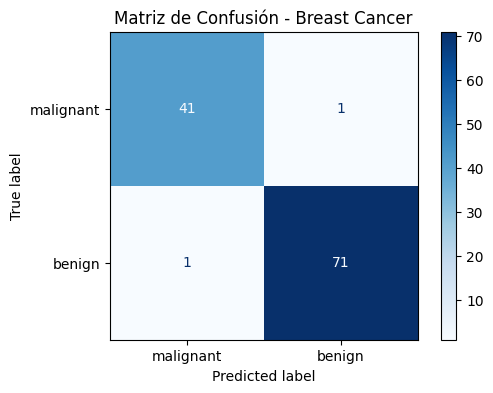

              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



In [ ]:
from sklearn.datasets import load_breast_cancer

# Cargar datos
cancer = load_breast_cancer()
X_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = pd.Series(cancer.target)

# Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

# Escalar
scaler_c = StandardScaler()
X_train_c_scaled = scaler_c.fit_transform(X_train_c)
X_test_c_scaled = scaler_c.transform(X_test_c)

# Entrenar
modelo_cancer = LogisticRegression(random_state=42)
modelo_cancer.fit(X_train_c_scaled, y_train_c)
y_pred_c = modelo_cancer.predict(X_test_c_scaled)

# Evaluar
cm_c = confusion_matrix(y_test_c, y_pred_c)
disp_c = ConfusionMatrixDisplay(confusion_matrix=cm_c, display_labels=['malignant', 'benign'])
fig, ax = plt.subplots(figsize=(6, 4))
disp_c.plot(cmap='Blues', ax=ax)
ax.set_title('Matriz de Confusión - Breast Cancer')
plt.show()

print(classification_report(y_test_c, y_pred_c, target_names=['malignant', 'benign']))





In [66]:
print("Distibucion de tipo de tumores para ver balance de clases\n")

print (f'{42/(42+72):.4f}' + f' maligno' )
print (f'{72/(42+72):.4f}' + f' maligno' )

Distibucion de tipo de tumores para ver balance de clases

0.3684 maligno
0.6316 maligno


## Análisis completo: estandarización, entrenamiento, evaluación con matriz de confusión y reporte de clasificación.

El modelo funciona muy bien, con 98% de accuracy y precision y recall altos para las dos clases. A diferencia del dataset de Default, acá las clases están más balanceadas, así que la accuracy no engaña y sirve como métrica para evaluar la performance del modelo. Lo más importante es que el recall de malignant es 0.98 — el modelo casi no deja pasar tumores malignos sin detectar, que es lo que más importa en un contexto médico. De esta manera, como precision y recall son muy altos, F1 score (que es la metrica que se construye a partir de la media armónica entre precision y recall) es alto.

## 4. ¿Qué representa un punto en la esquina superior izquierda de la curva ROC? ¿Y un punto en la línea diagonal?
La esquina superior izquierda es el punto ideal: detectás todos los positivos sin generar falsos positivos. La diagonal representa un modelo que no aprende nada, equivale a adivinar al azar (similar a tirar con una moneda). 

## 5. ¿Por qué es fundamental ajustar (fit) el StandardScaler únicamente con los datos de entrenamiento y no con todo el dataset?

Si ajustamos el scaler con todos los datos, el modelo termina viendo información del test set antes de ser evaluado, lo que causa que los "estadisticos" media y varianza, se vean influenciados por los datos de test. Eso hace que la evaluación final con los datos de test sea optimista y no refleje cómo va a funcionar con datos nuevos de verdad.

## 6. Creá un bucle for que itere sobre una lista de umbrales (ej. [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]). Para cada umbral, calculá y guardá la Precisión y el Recall para la clase 'Default'. Luego, graficá cómo cambian estas dos métricas a medida que varía el umbral (Precision-Recall Curve).





In [67]:

from sklearn.metrics import precision_score, recall_score

umbrales = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
precisiones = []
recalls = []

for umbral in umbrales:
    y_pred_u = (y_pred_proba >= umbral).astype(int)
    precisiones.append(precision_score(y_test, y_pred_u, zero_division=0))
    recalls.append(recall_score(y_test, y_pred_u))

fig = go.Figure()
fig.add_trace(go.Scatter(x=umbrales, y=precisiones, mode='lines+markers', name='Precision'))
fig.add_trace(go.Scatter(x=umbrales, y=recalls, mode='lines+markers', name='Recall'))
fig.update_layout(
    title='Precision y Recall vs Umbral de Decisión',
    xaxis_title='Umbral',
    yaxis_title='Score',
    template='plotly_white'
)
fig.show()


## Conclusion

El gráfico muestra el trade-off clásico: cuando sube el umbral, la Precision sube y el Recall baja, y viceversa. Se cruzan alrededor de 0.3, que es donde más equilibradas están las dos. Según lo que necesite el negocio, se elige el Umbral específico que alinee con los objetivos trazados.

## 7. Usando los coeficientes del modelo log_reg (entrenado con datos escalados), interpretá el coeficiente de la variable balance. ¿Qué significa un aumento de una desviación estándar en el balance en términos del odds ratio de default?

El coeficiente de balance es el más alto del modelo (~2.59). Como los datos están escalados, un aumento de una desviación estándar en el balance multiplica las chances de default por e^2.59 ≈ 13. Es el predictor más importante por lejos.

## 8. Explicá la diferencia fundamental entre la regularización L1 y L2 en términos de su efecto sobre los coeficientes del modelo.

Las dos penalizan coeficientes grandes para evitar overfitting, pero L2 los achica sin llegar a cero — todos los predictores siguen en el modelo. L1 en cambio puede llevar coeficientes exactamente a cero, eliminando esa variable del modelo directamente. Esto se da ya que L1 utiliza valores absolutos de los betas en vez del cuadrado de los mismos (L2), cuyo gradiente es ±1 constante sin importar cuán chico sea el β, a diferencia de L2 cuyo gradiente es 2β y se desvanece al achicarse beta.

## 9. Si tuvieras dos modelos, uno con AUC de 0.85 y otro con AUC de 0.75, ¿cuál elegirías y por qué? ¿Bajo qué circunstancias podrías preferir el de 0.75?

En general elegiría el de AUC 0.85 porque discrimina mejor. Pero si el de 0.75 es mucho más simple (por ejemplo si el de 0.85 es un modelo de caja negra), podría tener sentido preferir el 0.75 en contextos regulados como bancos o medicina, donde pueda existir una obligación de explicar el por qué de cada decisión que toma el modelo (algo que seria muy dificil con un modelo caja negra sin importar cuán bueno sea su AUC).

